# **EXPLORATORY DATA ANALYSIS OF THE SUPERSTORE SALES DATASET**

## **This project involves carrying out Exploratory Data Analysis on the Superstore Sales Dataset to uncover patterns, trends in sales, shipping methods, customer segments and categories. The analysis uses visualizations and summary statistics to uncover key business insights.**

## **IMPORTING RELEVANT LIBRARIES**

In [620]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **BASIC EXPLORATORY ANALYSIS**

In [621]:
# Read file
df = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/3MTT_Mentorship/Datasets/Superstore_Sales_Dataset.csv', index_col = 'Row ID')
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
Row ID,,,,,,,,,,,,,,,,,
1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [622]:
# Check columns
df.columns

Index(['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID',
       'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales'],
      dtype='object')

In [623]:
# Check number of rows and columns
df.shape

(9800, 17)

In [624]:
# check for duplicated
df.duplicated().sum()

np.int64(1)

In [625]:
# Remove duplicates
df.drop_duplicates(inplace = True)

In [626]:
#Confirm duplicates have been removed
df.shape

(9799, 17)

In [627]:
# Check for number of missing values in each columns
df.isnull().sum()

,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0
State,0


### The `Postal Code` column was seen to contain 11 missing values. This column is quite irrelevant to our EDA because it has a direct link to the country, city or state, therefore it will be dropped.

In [628]:
# Checking the summary statistics
df.describe()

,Postal Code,Sales
count,9788.000000,9799.000000
mean,55274.552922,230.763895
std,32042.628986,626.683644
min,1040.000000,0.444000
25%,23223.000000,17.248000
50%,58103.000000,54.480000
75%,90008.000000,210.572000
max,99301.000000,22638.480000


In [629]:
# Checking the data type of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9799 entries, 1 to 9800
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9799 non-null   object 
 1   Order Date     9799 non-null   object 
 2   Ship Date      9799 non-null   object 
 3   Ship Mode      9799 non-null   object 
 4   Customer ID    9799 non-null   object 
 5   Customer Name  9799 non-null   object 
 6   Segment        9799 non-null   object 
 7   Country        9799 non-null   object 
 8   City           9799 non-null   object 
 9   State          9799 non-null   object 
 10  Postal Code    9788 non-null   float64
 11  Region         9799 non-null   object 
 12  Product ID     9799 non-null   object 
 13  Category       9799 non-null   object 
 14  Sub-Category   9799 non-null   object 
 15  Product Name   9799 non-null   object 
 16  Sales          9799 non-null   float64
dtypes: float64(2), object(15)
memory usage: 1.3+ MB


## **DATA MANIPULATION**

In [630]:
# Round off the sales column to 2 decimal places
df['Sales'] = df['Sales'].round(2)

In [631]:
# Drop irrelevant columns
df.drop(columns = ['Order ID', 'Customer ID', 'Customer Name', 'Postal Code', 'Product ID', 'Product Name'], inplace = True)

In [632]:
# Converting the date columns to datetime data type
df['Order Date'] = df['Order Date'].str.strip()
df['Ship Date'] = df['Ship Date'].str.strip()

df['Order Date'] = pd.to_datetime(df['Order Date'], format = '%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format = '%d/%m/%Y')

In [633]:
# Inderting the order_year column
df['Order_year'] = df['Order Date'].dt.year.astype('str')
df.head()

,Order Date,Ship Date,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category,Sales,Order_year
Row ID,,,,,,,,,,,,
1,2017-11-08,2017-11-11,Second Class,Consumer,United States,Henderson,Kentucky,South,Furniture,Bookcases,261.96,2017
2,2017-11-08,2017-11-11,Second Class,Consumer,United States,Henderson,Kentucky,South,Furniture,Chairs,731.94,2017
3,2017-06-12,2017-06-16,Second Class,Corporate,United States,Los Angeles,California,West,Office Supplies,Labels,14.62,2017
4,2016-10-11,2016-10-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,South,Furniture,Tables,957.58,2016
5,2016-10-11,2016-10-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,South,Office Supplies,Storage,22.37,2016


In [634]:
# Confirming changes have been effected
df.head(3)

,Order Date,Ship Date,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category,Sales,Order_year
Row ID,,,,,,,,,,,,
1,2017-11-08,2017-11-11,Second Class,Consumer,United States,Henderson,Kentucky,South,Furniture,Bookcases,261.96,2017
2,2017-11-08,2017-11-11,Second Class,Consumer,United States,Henderson,Kentucky,South,Furniture,Chairs,731.94,2017
3,2017-06-12,2017-06-16,Second Class,Corporate,United States,Los Angeles,California,West,Office Supplies,Labels,14.62,2017


In [635]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9799 entries, 1 to 9800
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order Date    9799 non-null   datetime64[ns]
 1   Ship Date     9799 non-null   datetime64[ns]
 2   Ship Mode     9799 non-null   object        
 3   Segment       9799 non-null   object        
 4   Country       9799 non-null   object        
 5   City          9799 non-null   object        
 6   State         9799 non-null   object        
 7   Region        9799 non-null   object        
 8   Category      9799 non-null   object        
 9   Sub-Category  9799 non-null   object        
 10  Sales         9799 non-null   float64       
 11  Order_year    9799 non-null   object        
dtypes: datetime64[ns](2), float64(1), object(9)
memory usage: 995.2+ KB


## **EXPLORATORY DATA ANALYSIS**

In [636]:
df.columns.to_list()

['Order Date',
 'Ship Date',
 'Ship Mode',
 'Segment',
 'Country',
 'City',
 'State',
 'Region',
 'Category',
 'Sub-Category',
 'Sales',
 'Order_year']

In [637]:
for col in df.columns.to_list():
  print(f'Value Counts of {col}:')
  print(df[col].value_counts())
  print('\n')

Value Counts of Order Date:
Order Date
2017-09-05    38
2017-11-10    35
2018-12-01    34
2018-12-02    34
2018-12-09    33
              ..
2018-09-13     1
2016-01-24     1
2017-04-13     1
2018-03-14     1
2016-05-09     1
Name: count, Length: 1230, dtype: int64


Value Counts of Ship Date:
Ship Date
2018-09-26    34
2018-12-06    32
2016-12-16    31
2018-09-15    30
2018-12-12    30
              ..
2018-08-31     1
2016-10-25     1
2015-03-03     1
2017-06-05     1
2016-05-13     1
Name: count, Length: 1326, dtype: int64


Value Counts of Ship Mode:
Ship Mode
Standard Class    5858
Second Class      1902
First Class       1501
Same Day           538
Name: count, dtype: int64


Value Counts of Segment:
Segment
Consumer       5101
Corporate      2953
Home Office    1745
Name: count, dtype: int64


Value Counts of Country:
Country
United States    9799
Name: count, dtype: int64


Value Counts of City:
City
New York City    891
Los Angeles      728
Philadelphia     532
San Francisco  

In [638]:
df.columns

Index(['Order Date', 'Ship Date', 'Ship Mode', 'Segment', 'Country', 'City',
       'State', 'Region', 'Category', 'Sub-Category', 'Sales', 'Order_year'],
      dtype='object')

In [639]:
# Number of columns left
len(df.columns)

12

## **SEPARATING NUMERICAL AND CATEGORICAL COLUMNS AND DATETIME COLUMNS**

In [640]:
cat_cols = df.drop(columns = ['Order Date', 'Ship Date', 'Country', 'Sales'])
cat_cols.head()

,Ship Mode,Segment,City,State,Region,Category,Sub-Category,Order_year
Row ID,,,,,,,,
1,Second Class,Consumer,Henderson,Kentucky,South,Furniture,Bookcases,2017
2,Second Class,Consumer,Henderson,Kentucky,South,Furniture,Chairs,2017
3,Second Class,Corporate,Los Angeles,California,West,Office Supplies,Labels,2017
4,Standard Class,Consumer,Fort Lauderdale,Florida,South,Furniture,Tables,2016
5,Standard Class,Consumer,Fort Lauderdale,Florida,South,Office Supplies,Storage,2016


In [641]:
num_cols = df[['Sales']]
num_cols.head()

,Sales
Row ID,
1,261.96
2,731.94
3,14.62
4,957.58
5,22.37


In [642]:
date_cols = df[['Order Date', 'Ship Date']]
date_cols.head()

,Order Date,Ship Date
Row ID,,
1,2017-11-08,2017-11-11
2,2017-11-08,2017-11-11
3,2017-06-12,2017-06-16
4,2016-10-11,2016-10-18
5,2016-10-11,2016-10-18


## **UNIVARIATE ANALYSIS WITH CATEGORICAL FIELDS**

In [643]:
cat_cols.head()

,Ship Mode,Segment,City,State,Region,Category,Sub-Category,Order_year
Row ID,,,,,,,,
1,Second Class,Consumer,Henderson,Kentucky,South,Furniture,Bookcases,2017
2,Second Class,Consumer,Henderson,Kentucky,South,Furniture,Chairs,2017
3,Second Class,Corporate,Los Angeles,California,West,Office Supplies,Labels,2017
4,Standard Class,Consumer,Fort Lauderdale,Florida,South,Furniture,Tables,2016
5,Standard Class,Consumer,Fort Lauderdale,Florida,South,Office Supplies,Storage,2016


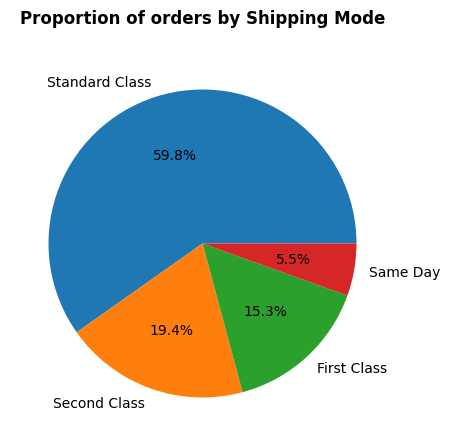

In [644]:
# Proportion of orders by Shipping Mode
plt.figure(figsize = (6.5, 5))
counts = df['Ship Mode'].value_counts()
plt.pie(counts, labels = counts.index, autopct='%1.1f%%')
plt.title('Proportion of orders by Shipping Mode', fontweight = 'bold', pad = 20, color = 'black', loc = 'center')
plt.show()

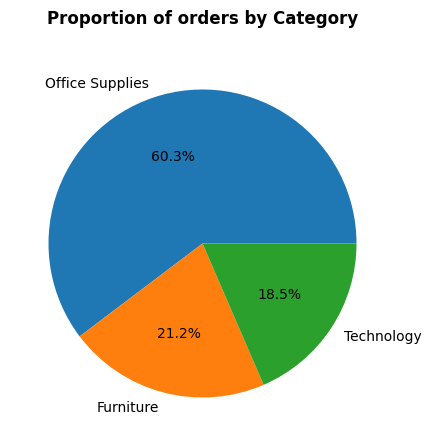

In [645]:
# Proportion of orders by Category
plt.figure(figsize = (6.5, 5))
counts = cat_cols['Category'].value_counts()
plt.pie(counts, labels = counts.index, autopct='%1.1f%%')
plt.title('Proportion of orders by Category', fontweight = 'bold', pad = 20)
plt.show()

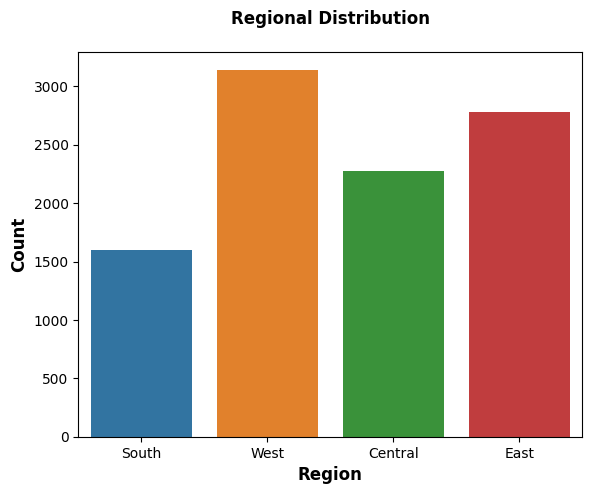

In [646]:
# Distribution by Region
plt.figure(figsize = (6.5, 5))
sns.countplot(data = df, x = 'Region', hue = 'Region')
plt.title('Regional Distribution', fontweight = 'bold', pad = 20)
plt.xlabel('Region', fontweight = 'bold', fontsize = 12)
plt.ylabel('Count', fontweight = 'bold', fontsize = 12)
plt.show()

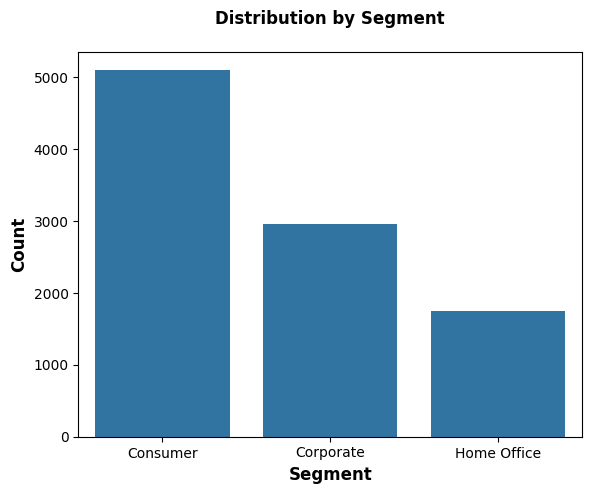

In [647]:
# Distribution by Segment
plt.figure(figsize = (6.5, 5))
sns.countplot(data = df, x = 'Segment')
plt.title('Distribution by Segment', fontweight = 'bold', pad = 20)
plt.xlabel('Segment', fontweight = 'bold', fontsize = 12)
plt.ylabel('Count', fontweight = 'bold', fontsize = 12)
plt.show()

## **UNIVARIATE ANALYSIS WITH THE NUMERICAL FIELD**

In [648]:
num_cols.columns

Index(['Sales'], dtype='object')

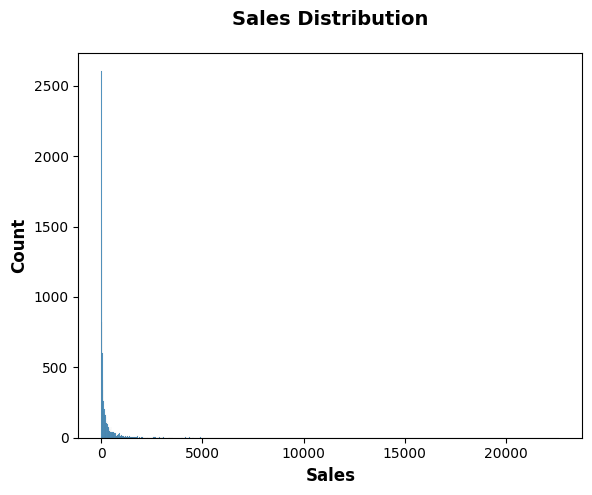

In [649]:
# Sales Distribution using a histplot
plt.figure(figsize = (6.5, 5))
sns.histplot(data = num_cols, x = 'Sales')
plt.title('Sales Distribution', fontweight = 'bold', fontsize = 14, pad = 20)
plt.xlabel('Sales', fontweight = 'bold', fontsize = 12)
plt.ylabel('Count', fontweight = 'bold', fontsize = 12)
plt.show()

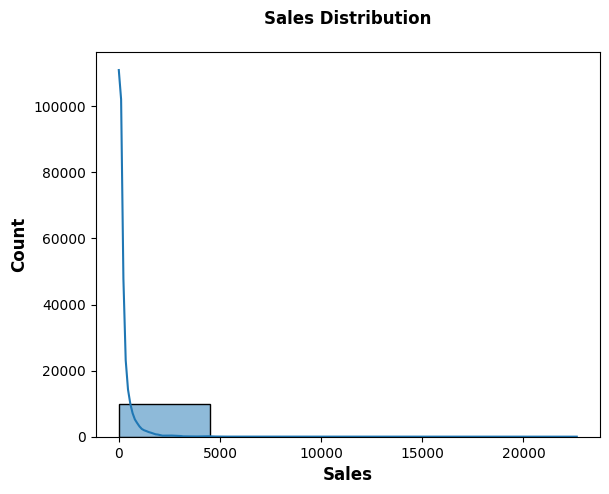

In [650]:
# Sales Distribution using a histplot with kde
plt.figure(figsize = (6.5, 5))
sns.histplot(data = num_cols, x = 'Sales', bins = 5, kde = True)
plt.title('Sales Distribution', fontweight = 'bold', pad = 20)
plt.xlabel('Sales', fontweight = 'bold', fontsize = 12)
plt.ylabel('Count', fontweight = 'bold', fontsize = 12)
plt.show()

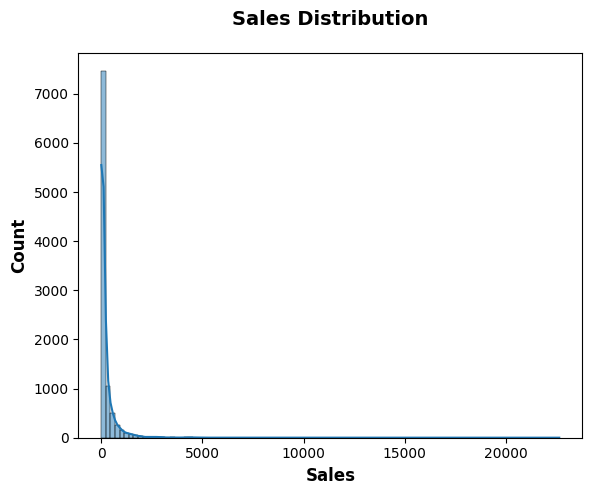

In [651]:
# Sales Distribution using a histplot with 100 bins
plt.figure(figsize = (6.5, 5))
sns.histplot(data = num_cols, x = 'Sales', bins = 100, kde = True)
plt.title('Sales Distribution', fontweight = 'bold', fontsize = 14, pad = 20)
plt.xlabel('Sales', fontweight = 'bold', fontsize = 12)
plt.ylabel('Count', fontweight = 'bold', fontsize = 12)
plt.show()

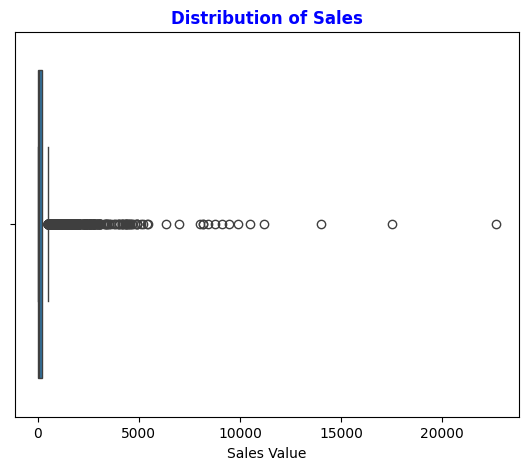

In [652]:
# Sales Distribution using a box plot as well as checking for outliers
plt.figure(figsize = (6.5, 5))
sns.boxplot(data = num_cols, x = 'Sales')
plt.title('Distribution of Sales', fontweight = 'bold', color = 'blue')
plt.xlabel('Sales Value')
plt.show()

## **BIVARIATE ANALYSIS - NUMERIC Vs NUMERIC**

In [653]:
date_cols.head()

,Order Date,Ship Date
Row ID,,
1,2017-11-08,2017-11-11
2,2017-11-08,2017-11-11
3,2017-06-12,2017-06-16
4,2016-10-11,2016-10-18
5,2016-10-11,2016-10-18


In [654]:
yearly_sales = df.groupby(order_year)['Sales'].sum()
yearly_sales = yearly_sales.reset_index()

In [655]:
yearly_sales.head()

,Order Date,Sales
0,2015,479574.81
1,2016,459435.87
2,2017,600192.68
3,2018,722051.82


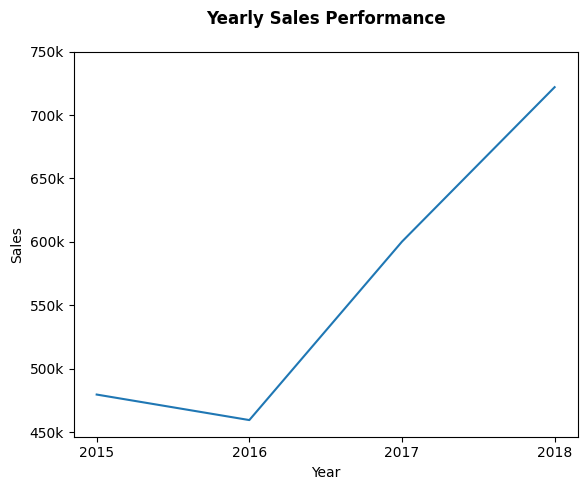

In [656]:
# Yearly Sales Performance
plt.figure(figsize = (6.5, 5))
sns.lineplot(data = yearly_sales, x = 'Order Date', y = 'Sales')
plt.title('Yearly Sales Performance', fontweight = 'bold', pad = 20)
plt.xlabel('Year')
plt.xticks(yearly_sales['Order Date'])
plt.ylabel('Sales')
plt.yticks([450000, 500000, 550000, 600000, 650000, 700000, 750000], ['450k', '500k', '550k', '600k', '650k', '700k', '750k'])
plt.show()

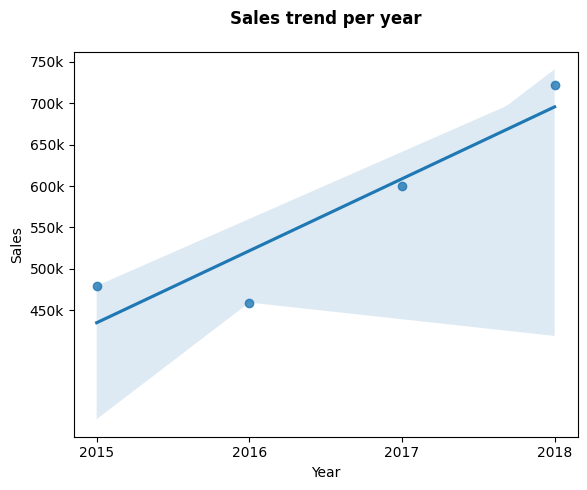

In [657]:
# Sales trend per year using Regression plot
plt.figure(figsize = (6.5, 5))
sns.regplot(data = yearly_sales, x = 'Order Date', y = 'Sales')
plt.title('Sales trend per year', fontweight = 'bold', pad = 20)
plt.xlabel('Year')
plt.xticks(yearly_sales['Order Date'])
plt.ylabel('Sales')
plt.yticks([450000, 500000, 550000, 600000, 650000, 700000, 750000], ['450k', '500k', '550k', '600k', '650k', '700k', '750k'])
plt.show()

## **BIVARIATE ANALYSIS - CATEGORICAL vs NUMERIC**

In [658]:
cat_cols.columns

Index(['Ship Mode', 'Segment', 'City', 'State', 'Region', 'Category',
       'Sub-Category', 'Order_year'],
      dtype='object')

In [659]:
ccols = ['Ship Mode', 'Segment', 'Region', 'Category']
for col in ccols:
  stats_analysis_df = df.groupby(col)['Sales'].agg(['mean', 'sum']).round(2).reset_index()
  print(stats_analysis_df)
  print('\n')

        Ship Mode    mean         sum
0     First Class  230.23   345572.15
1        Same Day  232.75   125219.00
2    Second Class  236.55   449914.00
3  Standard Class  228.84  1340550.03


       Segment    mean         sum
0     Consumer  225.07  1148060.29
1    Corporate  233.15   688494.02
2  Home Office  243.38   424700.87


    Region    mean        sum
0  Central  216.36  492646.78
1     East  240.39  669237.42
2    South  243.52  389151.38
3     West  226.18  710219.60


          Category    mean        sum
0        Furniture  350.69  728377.13
1  Office Supplies  119.38  705422.19
2       Technology  456.40  827455.86




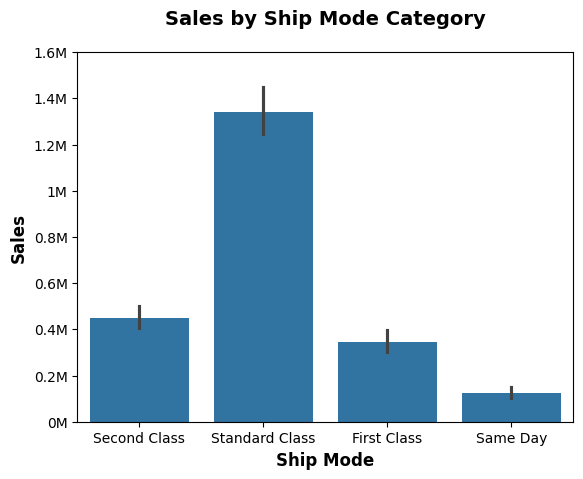

In [660]:
# Total Sales by Ship Mode
sns.barplot(data = df, x = 'Ship Mode', y ='Sales', estimator = np.sum)
plt.title('Sales by Ship Mode Category', fontweight = 'bold', fontsize = 14, pad = 20)
plt.xlabel('Ship Mode', fontweight = 'bold', fontsize = 12)
plt.ylabel('Sales', fontweight = 'bold', fontsize = 12)
plt.yticks([0, 200000, 400000, 600000, 800000, 1000000, 1200000, 1400000, 1600000], ['0M', '0.2M', '0.4M', '0.6M', '0.8M', '1M', '1.2M', '1.4M', '1.6M'])
plt.show()

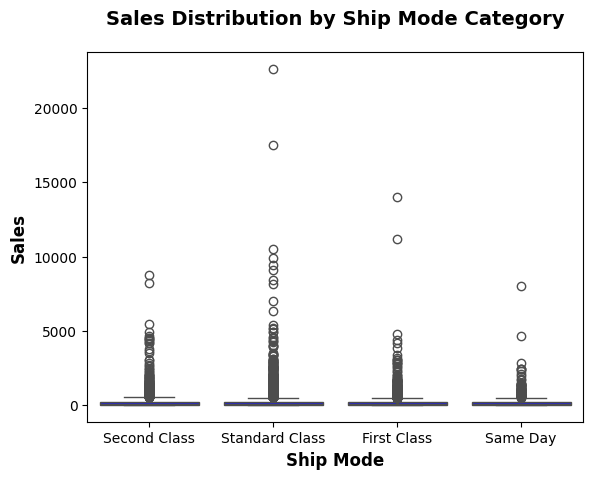

In [661]:
# Sales Distribution by Ship Mode Category
sns.boxplot(data = df, x = 'Ship Mode', y ='Sales', color = 'blue')
plt.title('Sales Distribution by Ship Mode Category', fontweight = 'bold', fontsize = 14, pad = 20)
plt.xlabel('Ship Mode', fontweight = 'bold', fontsize = 12)
plt.ylabel('Sales', fontweight = 'bold', fontsize = 12)
plt.show()

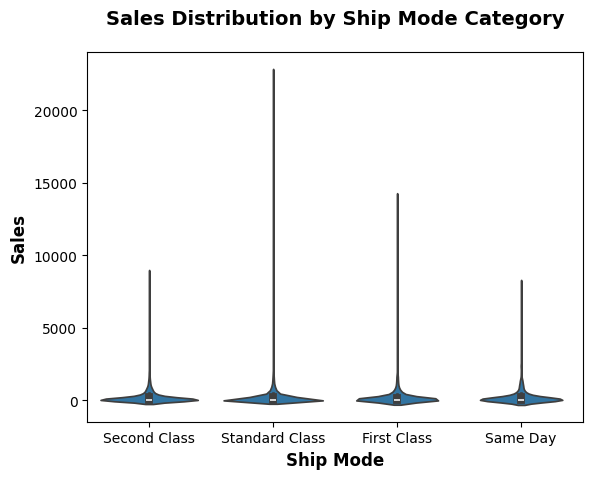

In [662]:
# Sales Distribution by Ship Mode
sns.violinplot(data = df, x = 'Ship Mode', y ='Sales')
plt.title('Sales Distribution by Ship Mode Category', fontweight = 'bold', fontsize = 14, pad = 20)
plt.xlabel('Ship Mode', fontweight = 'bold', fontsize = 12)
plt.ylabel('Sales', fontweight = 'bold', fontsize = 12)
plt.show()

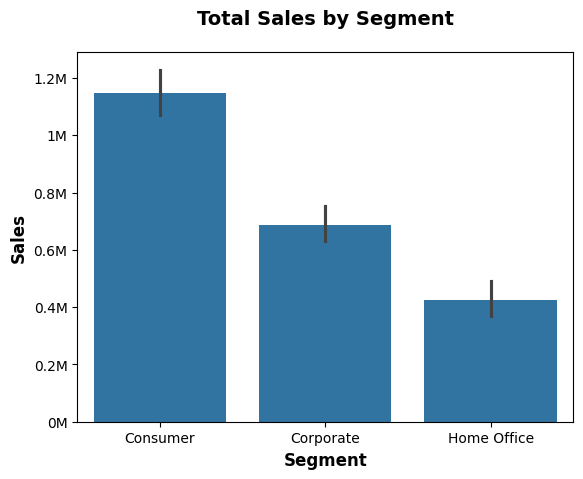

In [663]:
# Total Sales by Segment
sns.barplot(data = df, x = 'Segment', y ='Sales', estimator = np.sum)
plt.title('Total Sales by Segment', fontweight = 'bold', fontsize = 14, pad = 20)
plt.xlabel('Segment', fontweight = 'bold', fontsize = 12)
plt.ylabel('Sales', fontweight = 'bold', fontsize = 12)
plt.yticks([0, 200000, 400000, 600000, 800000, 1000000, 1200000], ['0M', '0.2M', '0.4M', '0.6M', '0.8M', '1M', '1.2M'])
plt.show()

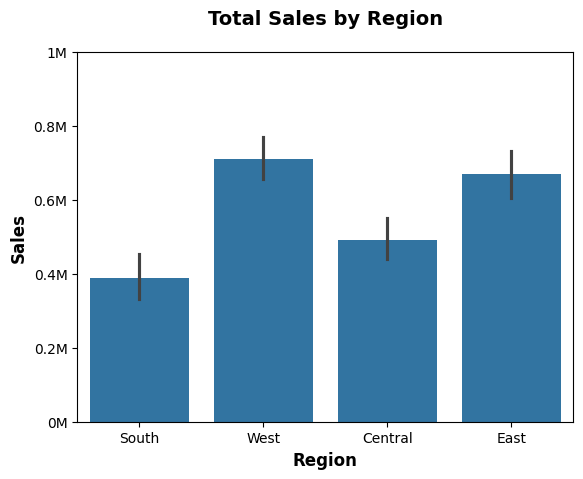

In [664]:
# Total Sales by Region
sns.barplot(data = df, x = 'Region', y ='Sales', estimator = np.sum)
plt.title('Total Sales by Region', fontweight = 'bold', fontsize = 14, pad = 20)
plt.xlabel('Region', fontweight = 'bold', fontsize = 12)
plt.ylabel('Sales', fontweight = 'bold', fontsize = 12)
plt.yticks([0, 200000, 400000, 600000, 800000, 1000000], ['0M', '0.2M', '0.4M', '0.6M', '0.8M', '1M'])
plt.show()

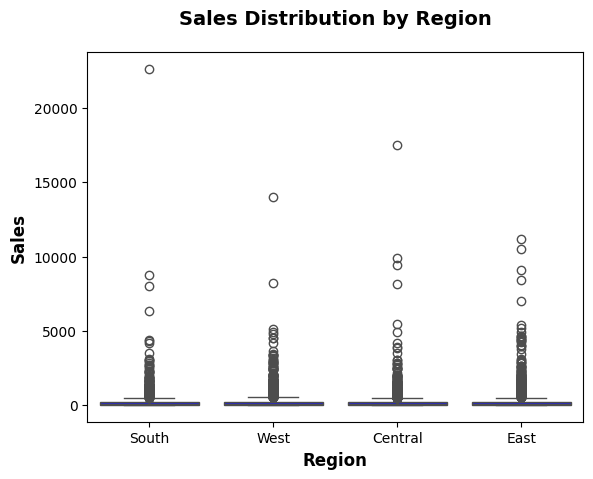

In [665]:
# Checking for outliers using boxplox
sns.boxplot(data = df, x = 'Region', y ='Sales', color = 'blue')
plt.title('Sales Distribution by Region', fontweight = 'bold', fontsize = 14, pad = 20)
plt.xlabel('Region', fontweight = 'bold', fontsize = 12)
plt.ylabel('Sales', fontweight = 'bold', fontsize = 12)
plt.show()

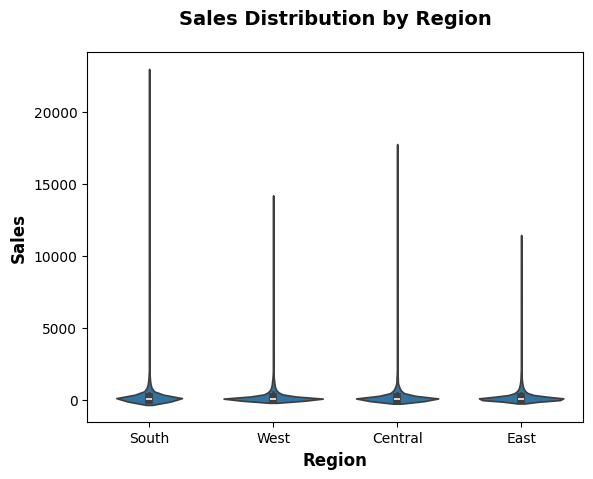

In [666]:
# Sales Distribution by Region
sns.violinplot(data = df, x = 'Region', y ='Sales')
plt.title('Sales Distribution by Region', fontweight = 'bold', fontsize = 14, pad = 20)
plt.xlabel('Region', fontweight = 'bold', fontsize = 12)
plt.ylabel('Sales', fontweight = 'bold', fontsize = 12)
plt.show()

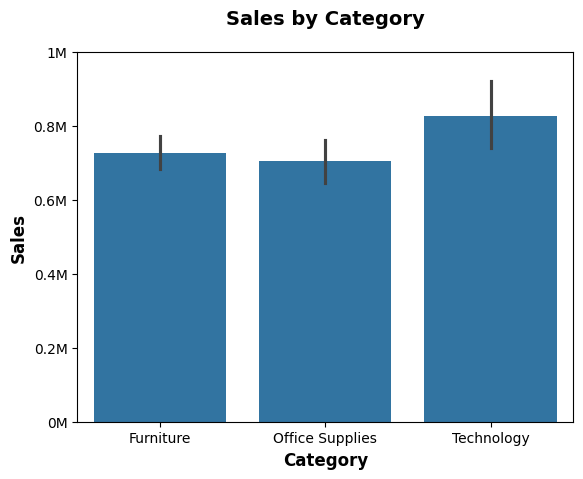

In [667]:
# Sales by Category
sns.barplot(data = df, x = 'Category', y ='Sales', estimator = np.sum)
plt.title('Sales by Category', fontweight = 'bold', fontsize = 14, pad = 20)
plt.xlabel('Category', fontweight = 'bold', fontsize = 12)
plt.ylabel('Sales', fontweight = 'bold', fontsize = 12)
plt.yticks([0, 200000, 400000, 600000, 800000, 1000000], ['0M', '0.2M', '0.4M', '0.6M', '0.8M', '1M'])
plt.show()

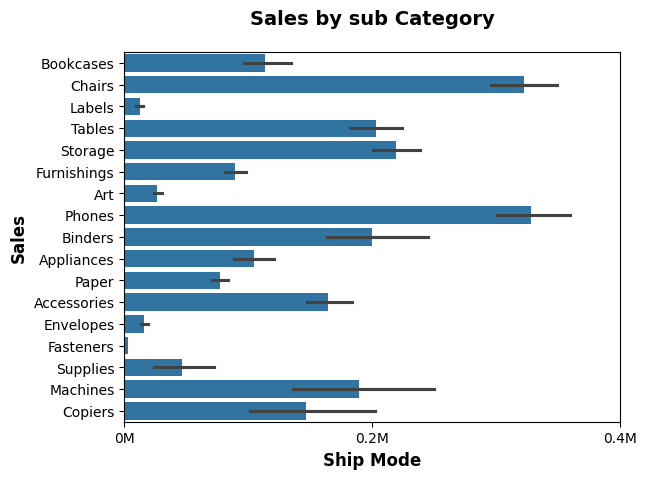

In [668]:
# Sales by Sub-Category
sns.barplot(data = df, y = 'Sub-Category', x ='Sales', estimator = np.sum)
plt.title('Sales by sub Category', fontweight = 'bold', fontsize = 14, pad = 20)
plt.xlabel('Ship Mode', fontweight = 'bold', fontsize = 12)
plt.xticks([0, 200000, 400000], ['0M', '0.2M', '0.4M'])
plt.ylabel('Sales', fontweight = 'bold', fontsize = 12)
plt.show()

## **BIVARIATE ANALYSIS - CATEGORICAL vs CATEGORICAL**

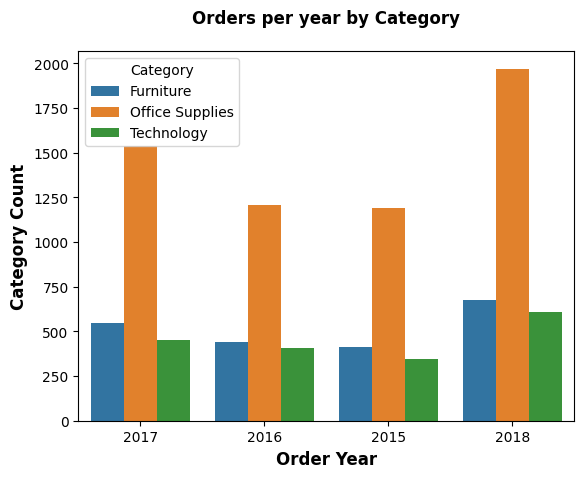

In [669]:
# Number of orders per year by Category
sns.countplot(data = df, x = 'Order_year', hue = 'Category')
plt.title('Orders per year by Category', fontweight = 'bold', pad = 20)
plt.xlabel('Order Year', fontweight = 'bold', fontsize = 12)
plt.ylabel('Category Count', fontweight = 'bold', fontsize = 12)
plt.show()

Text(0, 0.5, 'Segment Count')

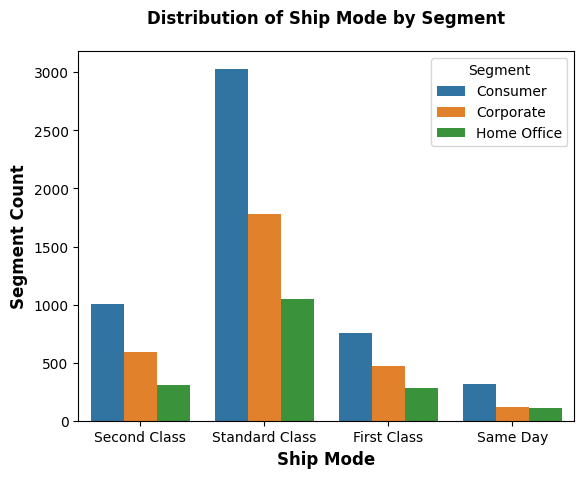

In [670]:
# Segment count per Ship Mode
sns.countplot(data = df, x = 'Ship Mode', hue = 'Segment')
plt.title('Distribution of Ship Mode by Segment', fontweight = 'bold', pad = 20)
plt.xlabel('Ship Mode', fontweight = 'bold', fontsize = 12)
plt.ylabel('Segment Count', fontweight = 'bold', fontsize = 12)

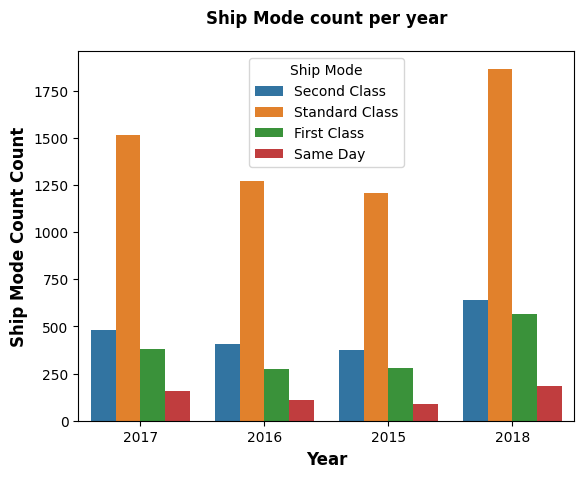

In [671]:
#Ship Mode Count per year
sns.countplot(data = df, x = 'Order_year', hue = 'Ship Mode')
plt.title('Ship Mode count per year', fontweight = 'bold', pad = 20)
plt.xlabel('Year', fontweight = 'bold', fontsize = 12)
plt.ylabel('Ship Mode Count Count', fontweight = 'bold', fontsize = 12)
plt.show()

# **Workflow - Exploratory Data Analysis of Retail Sales Dataset**

**Workflow**

Relevant libraries were imported, including pandas, numpy, matplotlib, and seaborn. Basic exploratory analysis was carried out to understand the dataset. The dataset was loaded, and the number of rows and columns was checked. Duplicate records and missing values were identified and removed where necessary. Summary statistics and general information about the dataset were also examined.

**Data Manipulation**
Data manipulation was then performed. The Sales column was rounded to two decimal places, irrelevant columns were dropped, and data type conversions were made for the date columns. A new column, Year, was created from the date column to enable easier time-based analysis. These changes were verified to ensure they were successfully applied.

**Exploratory Data Analysis (EDA)**
Exploratory data analysis was carried out hierarchically, starting from univariate analysis and progressing to bivariate analysis. The dataset columns were first separated into numerical, categorical, and datetime variables.

**Results**
**Univariate Analysis**
Univariate analysis was conducted on the categorical variables. The results showed that Standard Class in the shipping mode had the highest proportion of orders (59.8%), followed by Second Class with 19.4%. The analysis also revealed that Office Supplies had the highest proportion of orders (60.3%) by product category. In terms of regional distribution, the West region had the highest number of orders, while the South had the least. The Consumer segment recorded the highest distribution, with the Home Office segment being the least. Univariate analysis on the numerical variable (Sales) revealed the presence of several outliers. The sales distribution was right-skewed, indicating that most sales values are relatively low with a few very large transactions. A boxplot further confirmed the presence of multiple outliers in the sales data.

**Bivariate Analysis**
Bivariate analysis was conducted to examine relationships between variables. Analysis of yearly sales performance showed an overall positive trend beginning from 2016, although there was a decline in sales between 2015 and 2016, making 2016 the year with the lowest sales. Further analysis revealed customers’ preferences across shipping modes, with Standard Class generating the highest sales. Regional analysis showed that the West region recorded the highest sales. Product category analysis indicated that Technology products generated the highest sales. At the sub-category level, Chairs were the most sold items, while Fasteners recorded the lowest sales

**Recommendations**
- Outliers should ne removed from the dataset
- Advertising should be carried out for products with low sales since customers may not be aware of them.
- Advertisement should be carried out in regions with low sales. Predominantly sold products in certain regions should be analyzed and made more available.
- More chairs and technology products shouls be made available.